In [1]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_rangeCheck/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


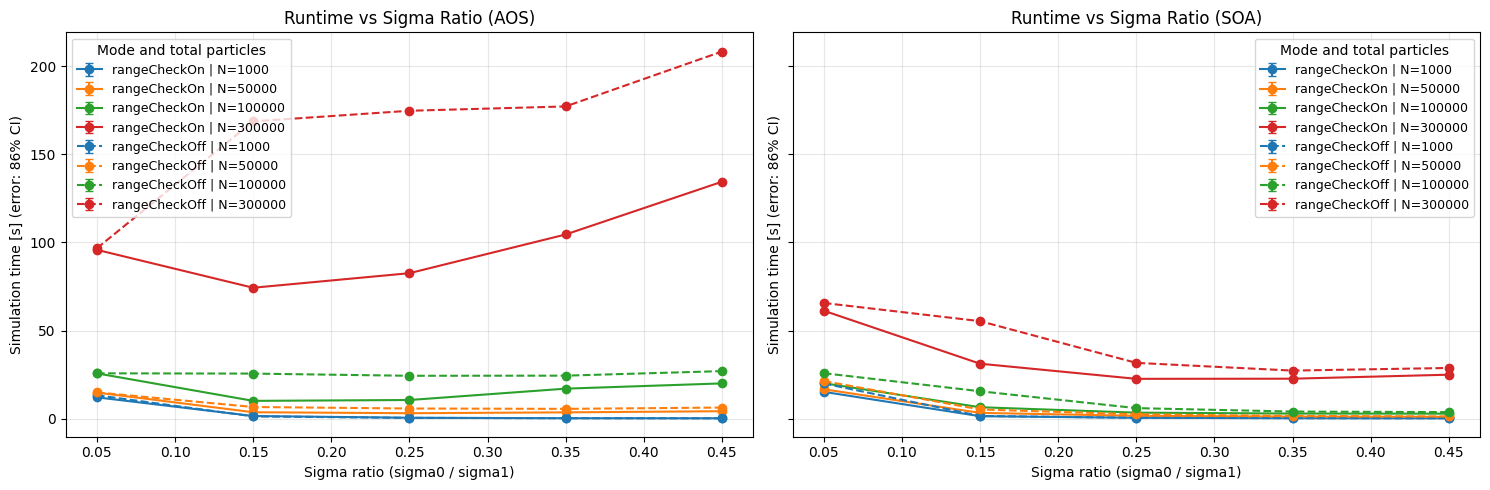

,range_check,total_particles,sigma_ratio,data_layout,run,seconds,log_file
149,rangeCheckOff,1000,0.05,AoS,0,13.204,/home/alex_hackerman/bachelorInfo/AutoPas/perf...
147,rangeCheckOff,1000,0.05,AoS,1,12.866,/home/alex_hackerman/bachelorInfo/AutoPas/perf...
148,rangeCheckOff,1000,0.05,AoS,2,13.670,/home/alex_hackerman/bachelorInfo/AutoPas/perf...
179,rangeCheckOff,1000,0.15,AoS,0,1.165,/home/alex_hackerman/bachelorInfo/AutoPas/perf...
177,rangeCheckOff,1000,0.15,AoS,1,1.251,/home/alex_hackerman/bachelorInfo/AutoPas/perf...


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml if not encoded in path."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def infer_range_check_mode(parts: tuple[str, ...]) -> str | None:
    """Infer whether a run belongs to rangeCheckOn or rangeCheckOff from path parts."""
    for token in parts:
        if token in {"rangeCheckOn", "rangeCheckOff"}:
            return token
    return None


def collect_runtime_data(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively.

    Supports both layouts:
    - .../rangeCheckOn|rangeCheckOff/totalParticles_<N>/sigmaRatio_.../countRatio_.../dataLayout_.../run_.../logOutput_...
    - .../rangeCheckOn|rangeCheckOff/sigmaRatio_.../countRatio_.../dataLayout_.../run_.../logOutput_...

    Returns one row per run with columns:
    range_check, total_particles, sigma_ratio, data_layout, run, seconds, log_file
    """
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        range_check = infer_range_check_mode(parts)
        if range_check is None:
            continue

        if not any(p.startswith("sigmaRatio_") for p in parts):
            continue
        if not any(p.startswith("dataLayout_") for p in parts):
            continue
        if not any(p.startswith("run_") for p in parts):
            continue

        sigma_ratio_str = next(p.split("_")[1] for p in parts if p.startswith("sigmaRatio_"))
        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        data_layout = next(p.split("_")[1] for p in parts if p.startswith("dataLayout_"))
        run = int(next(p.split("_")[1] for p in parts if p.startswith("run_")))

        total_dir = next((p for p in parts if p.startswith("totalParticles_")), None)
        if total_dir is not None:
            total_particles = int(total_dir.split("_")[1])
        else:
            total_particles = infer_total_particles_from_input(log_path.parent)
            if total_particles is None:
                continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "range_check": range_check,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "data_layout": data_layout,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    # Normal approximation fallback when SciPy is unavailable.
    # For confidence=0.86 this is approximately one sigma (z ~ 1.08).
    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def plot_runtime_vs_sigma(
    df: pd.DataFrame,
    data_layout: str,
    ax=None,
    error_mode: str = "t86",
):
    """Plot mean runtime vs sigma ratio for one data layout with error bars.

    Error modes:
    - "t86": 86% CI using Student's t over runs (requested one-sigma style)
    - "t95": 95% CI using Student's t over runs
    - "std": standard deviation over runs
    """
    subset = df[df["data_layout"].str.lower() == data_layout.lower()].copy()
    subset = subset[~subset["sigma_ratio"].round(2).eq(0.55)].copy()
    if subset.empty:
        raise ValueError(f"No rows found for data_layout={data_layout!r}.")

    summary = (
        subset.groupby(["range_check", "total_particles", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["range_check", "total_particles", "sigma_ratio"])
)

    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
        ylabel = "Simulation time [s] (error: std)"
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]
        ylabel = f"Simulation time [s] (error: {int(confidence * 100)}% CI)"

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    # Assign colors per total_particles
    unique_particles = sorted(summary["total_particles"].unique())
    colors = plt.cm.tab10(range(len(unique_particles)))
    particle_color_map = {p: colors[i] for i, p in enumerate(unique_particles)}

    line_styles = {"rangeCheckOn": "-", "rangeCheckOff": "--"}
    mode_order = ["rangeCheckOn", "rangeCheckOff"]
    for mode in mode_order:
        mode_subset = summary[summary["range_check"] == mode]
        for total_particles, grp in mode_subset.groupby("total_particles"):
            color = particle_color_map[total_particles]
            ax.errorbar(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                yerr=grp["error"],
                marker="o",
                linestyle=line_styles.get(mode, "-"),
                capsize=3,
                color=color,
                label=f"{mode} | N={total_particles}",
            )

    ax.set_title(f"Runtime vs Sigma Ratio ({data_layout.upper()})")
    ax.set_xlabel("Sigma ratio (sigma0 / sigma1)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Mode and total particles", fontsize=9)


# Collect and plot (search recursively from current notebook directory)
runtime_df = collect_runtime_data(".")

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    plot_runtime_vs_sigma(runtime_df, "AoS", ax=axes[0], error_mode="t86")
    plot_runtime_vs_sigma(runtime_df, "SoA", ax=axes[1], error_mode="t86")

    plt.tight_layout()
    plt.show()

    display(runtime_df.sort_values(["range_check", "data_layout", "total_particles", "sigma_ratio", "run"]).head())


In [6]:
# Check whether rangeCheckOff is ever faster than rangeCheckOn for the same setup.
comparison_df = runtime_df[~runtime_df["sigma_ratio"].round(2).eq(0.55)].copy()

summary = (
    comparison_df.groupby(["range_check", "data_layout", "total_particles", "sigma_ratio"], as_index=False)
    .agg(mean_seconds=("seconds", "mean"), n=("seconds", "count"))
)

pivot = summary.pivot_table(
    index=["data_layout", "total_particles", "sigma_ratio"],
    columns="range_check",
    values="mean_seconds",
)

required_cols = {"rangeCheckOn", "rangeCheckOff"}
if not required_cols.issubset(set(pivot.columns)):
    print("Could not compare both modes for all settings (missing rangeCheckOn or rangeCheckOff).")
else:
    pivot = pivot.reset_index()
    pivot["off_minus_on_s"] = pivot["rangeCheckOff"] - pivot["rangeCheckOn"]
    better_off = pivot[pivot["off_minus_on_s"] < 0].sort_values("off_minus_on_s")

    total_points = len(pivot)
    print(f"Comparable settings: {total_points}")
    print(f"Settings where rangeCheckOff is faster: {len(better_off)}")

    if better_off.empty:
        print("Result: No, rangeCheckOff is never faster in this dataset.")
    else:
        print("Result: Yes, rangeCheckOff is faster for these settings:")
        display(better_off)

    # Optional overall means across all runs (excluding sigma=0.55).
    overall = (
        comparison_df.groupby("range_check", as_index=False)
        .agg(mean_seconds=("seconds", "mean"), median_seconds=("seconds", "median"), n=("seconds", "count"))
    )
    display(overall)

Comparable settings: 40
Settings where rangeCheckOff is faster: 6
Result: Yes, rangeCheckOff is faster for these settings:


range_check,data_layout,total_particles,sigma_ratio,rangeCheckOff,rangeCheckOn,off_minus_on_s
1,AoS,1000,0.15,1.249333,1.467667,-0.218333
2,AoS,1000,0.25,0.407333,0.481000,-0.073667
4,AoS,1000,0.45,0.147667,0.177667,-0.030000
24,SoA,1000,0.45,0.168000,0.183333,-0.015333
22,SoA,1000,0.25,0.459333,0.470000,-0.010667
3,AoS,1000,0.35,0.214000,0.216333,-0.002333


,range_check,mean_seconds,median_seconds,n
0,rangeCheckOff,33.104925,14.1865,120
1,rangeCheckOn,21.435717,8.2865,120


In [13]:
import math
import numpy as np
import pandas as pd


def _cellblock3d_cell_length(box_min, box_max, interaction_length, cell_size_factor=1.0):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellSizeFactor."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min

    # CellBlock3D behavior for csf >= 1.0 / < 1.0 only affects halo width, not owned cell length.
    cells_per_dim = np.maximum(np.floor(box_lengths / (interaction_length * cell_size_factor)).astype(int), 1)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def _cellblock3d_cell_length_from_cells_per_dim(box_min, box_max, cells_per_dim):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellsPerDimension."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min
    cells_per_dim = np.asarray(cells_per_dim, dtype=int)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def hgmatching_cell_sizes_both_modes(
    sigma_ratios,
    box_min=(0.0, 0.0, 0.0),
    box_max=(20.0, 20.0, 20.0),
    skin=0.1,
    higher_cutoff=3.0,
    cell_size_factor=1.0,
    sigma_max=1.0,
    cutoff_scale=3.0,
    use_generator_rounding=True,
):
    """
    Mimic HierarchicalGridMatching + LinkedCells + CellBlock3D for both fittedGrids=false and fittedGrids=true.

    Returns per sigma ratio:
    - higher cell length
    - lower cell length for fittedGrids=false (ratio-based csf)
    - lower cell length for fittedGrids=true (cellsPerDimension path)
    - lowerCellsPerHigher check values
    """
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)

    max_length = float(np.min(box_max - box_min) - skin)
    out = []

    for sigma_ratio in sigma_ratios:
        sigma0 = sigma_max * float(sigma_ratio)
        cutoff0 = cutoff_scale * sigma0
        if use_generator_rounding:
            # input_generator writes cutoff0 with 6 decimals.
            cutoff0 = float(f"{cutoff0:.6f}")

        # Mimic constructor preprocessing: clamp > maxLength, sort, unique.
        cutoffs = sorted({min(cutoff0, max_length), min(higher_cutoff, max_length)})

        # Highest level (always constructed first with cellSizeFactor).
        highest_interaction = cutoffs[-1] + skin
        higher_cell_length, higher_cells_per_dim = _cellblock3d_cell_length(
            box_min, box_max, highest_interaction, cell_size_factor
        )

        # If lower cutoff collapsed away through uniqueness, only one level exists.
        if len(cutoffs) < 2:
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": np.array([np.nan, np.nan, np.nan]),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        lower_interaction = cutoffs[0] + skin

        # Pre-check in HierarchicalGridMatching before branch on fittedGrids.
        lower_cells_per_higher = np.floor(higher_cell_length / (lower_interaction * cell_size_factor)).astype(int)
        if np.any(lower_cells_per_higher < 2):
            # Level removed, hierarchy degenerates to highest level only.
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": lower_cells_per_higher.copy(),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        # fittedGrids == false branch: ratio-based cellSizeFactor for lower level.
        ratio = lower_interaction / highest_interaction
        lower_csf = cell_size_factor * ratio
        lower_cell_length_false, _ = _cellblock3d_cell_length(box_min, box_max, highest_interaction, lower_csf)

        # fittedGrids == true branch: explicitly matched cellsPerDimension.
        lower_cells_per_dim_true = lower_cells_per_higher * higher_cells_per_dim
        lower_cell_length_true, _ = _cellblock3d_cell_length_from_cells_per_dim(
            box_min, box_max, lower_cells_per_dim_true
        )

        out.append(
            {
                "sigma_ratio": float(sigma_ratio),
                "num_levels": 2,
                "lower_cells_per_higher": lower_cells_per_higher.copy(),
                "higher_cell_length": higher_cell_length.copy(),
                "lower_cell_length_false": lower_cell_length_false.copy(),
                "lower_cell_length_true": lower_cell_length_true.copy(),
            }
        )

    return out


# Example on your current gridFit sigma ratios.
sigmas = np.linspace(0.05, 0.50, 10)
res = hgmatching_cell_sizes_both_modes(sigmas)

df = pd.DataFrame(
    {
        "sigma_ratio": [r["sigma_ratio"] for r in res],
        "num_levels": [r["num_levels"] for r in res],
        "lower_cells_per_higher_x": [
            (int(r["lower_cells_per_higher"][0]) if not np.isnan(r["lower_cells_per_higher"][0]) else np.nan)
            for r in res
        ],
        "higher_cell_length_x": [r["higher_cell_length"][0] for r in res],
        "higher_over_lower_false_x": [r["higher_cell_length"][0] / r["lower_cell_length_false"][0] for r in res],
        "higher_over_lower_true_x": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in res],
    }
)

df

,sigma_ratio,num_levels,lower_cells_per_higher_x,higher_cell_length_x,higher_over_lower_false_x,higher_over_lower_true_x
0,0.05,2,13,3.333333,13.333333,13.0
1,0.10,2,8,3.333333,8.333333,8.0
2,0.15,2,6,3.333333,6.000000,6.0
3,0.20,2,4,3.333333,4.666667,4.0
4,0.25,2,3,3.333333,3.833333,3.0
5,0.30,2,3,3.333333,3.333333,3.0
6,0.35,2,2,3.333333,2.833333,2.0
7,0.40,2,2,3.333333,2.500000,2.0
8,0.45,2,2,3.333333,2.166667,2.0
9,0.50,2,2,3.333333,2.000000,2.0
